In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("Combined_dataset.csv")

## DATA EXPLORATION

In [10]:
print("No. of rows and columns: ", df.shape)
print("\n Column names: ", df.columns.tolist())
print("\n Data types pf each column:\n", df.dtypes)
print("\n First 5 rows:\n", df.head())
print("\n Last 5 rows:\n", df.tail())

No. of rows and columns:  (1000, 24)

 Column names:  ['product_id', 'title', 'product_description', 'rating', 'ratings_count', 'initial_price', 'discount', 'final_price', 'currency', 'images', 'delivery_options', 'product_details', 'breadcrumbs', 'product_specifications', 'amount_of_stars', 'what_customers_said', 'seller_name', 'sizes', 'videos', 'seller_information', 'variations', 'best_offer', 'more_offers', 'category']

 Data types pf each column:
 product_id                  int64
title                         str
product_description           str
rating                    float64
ratings_count               int64
initial_price               int64
discount                  float64
final_price                   str
currency                      str
images                        str
delivery_options              str
product_details               str
breadcrumbs                   str
product_specifications        str
amount_of_stars               str
what_customers_said           str

### Summary Statistics

In [17]:
df.describe(include='all')

,product_id,title,product_description,rating,ratings_count,initial_price,discount,final_price,currency,images,...,amount_of_stars,what_customers_said,seller_name,sizes,videos,seller_information,variations,best_offer,more_offers,category
count,1.000000e+03,1000,1000,1000.0000,1000.000000,1000.00000,879.000000,1000,1000,1000,...,1000,427,699,1000,219,699,438,1000,1000,1000
unique,NaN,454,989,NaN,NaN,NaN,NaN,466,1,1000,...,808,302,301,672,219,298,22,468,159,97
top,NaN,Roadster,Women Pink Solid Top,NaN,NaN,NaN,NaN,"""₹999.00""",INR,http://assets.myntassets.com/assets/images/837...,...,"{""1_star"":0,""2_stars"":0,""3_stars"":0,""4_stars"":...","[{""percentage"":""100"",""value_name"":""Fit, Just R...",Sup███om ███,"[{""size"":""Onesize""}]","[""rw-8376765_cae700""]",Plo███o- ███ 1s█████████Sui███████████████████...,[{}],{},"[{""offer_name"":""10% Instant Discount on IndusI...",tops
freq,NaN,30,3,NaN,NaN,NaN,NaN,25,1000,1,...,114,27,40,135,1,40,126,306,265,122
mean,1.713437e+07,NaN,NaN,3.6215,76.691000,2723.24100,53.503982,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,3.813766e+06,NaN,NaN,1.3744,241.114263,2408.69736,18.029201,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,5.868460e+05,NaN,NaN,0.0000,0.000000,249.00000,1.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.511501e+07,NaN,NaN,3.7000,7.000000,1399.00000,44.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.820890e+07,NaN,NaN,4.1000,17.000000,1999.00000,56.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.902737e+07,NaN,NaN,4.3000,58.000000,3299.00000,66.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   product_id              1000 non-null   int64  
 1   title                   1000 non-null   str    
 2   product_description     1000 non-null   str    
 3   rating                  1000 non-null   float64
 4   ratings_count           1000 non-null   int64  
 5   initial_price           1000 non-null   int64  
 6   discount                879 non-null    float64
 7   final_price             1000 non-null   str    
 8   currency                1000 non-null   str    
 9   images                  1000 non-null   str    
 10  delivery_options        1000 non-null   str    
 11  product_details         1000 non-null   str    
 12  breadcrumbs             1000 non-null   str    
 13  product_specifications  1000 non-null   str    
 14  amount_of_stars         1000 non-null   str    
 15 

In [20]:
df.nunique()

product_id                1000
title                      454
product_description        989
rating                      34
ratings_count              221
initial_price              256
discount                    81
final_price                466
currency                     1
images                    1000
delivery_options            16
product_details            998
breadcrumbs                658
product_specifications     967
amount_of_stars            808
what_customers_said        302
seller_name                301
sizes                      672
videos                     219
seller_information         298
variations                  22
best_offer                 468
more_offers                159
category                    97
dtype: int64

In [21]:
df['category'].value_counts()

category
tops            122
dresses         100
shirts           97
jeans            57
sports-shoes     51
               ... 
tights            1
towel-set         1
trolley-bag       1
wall-art          1
yoga-mats         1
Name: count, Length: 97, dtype: int64

### Missing data analysis

In [24]:

missing = df.isnull().sum()
missing_pct = 100 * missing / len(df)
missing_table = pd.concat([missing, missing_pct], axis=1, keys=['Count', '%'])
print(missing_table)


                        Count     %
product_id                  0   0.0
title                       0   0.0
product_description         0   0.0
rating                      0   0.0
ratings_count               0   0.0
initial_price               0   0.0
discount                  121  12.1
final_price                 0   0.0
currency                    0   0.0
images                      0   0.0
delivery_options            0   0.0
product_details             0   0.0
breadcrumbs                 0   0.0
product_specifications      0   0.0
amount_of_stars             0   0.0
what_customers_said       573  57.3
seller_name               301  30.1
sizes                       0   0.0
videos                    781  78.1
seller_information        301  30.1
variations                562  56.2
best_offer                  0   0.0
more_offers                 0   0.0
category                    0   0.0


<Axes: >

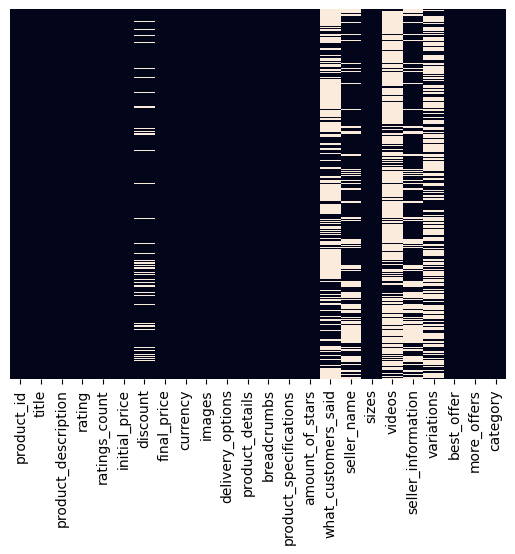

In [25]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)

### Data Types and memory usage

In [27]:
df.dtypes
df.memory_usage(deep=True)          

Index                         132
product_id                   8000
title                       58520
product_description         92917
rating                       8000
ratings_count                8000
initial_price                8000
discount                     8000
final_price                 99171
currency                     1052
images                     942227
delivery_options           177361
product_details            381716
breadcrumbs                372453
product_specifications    1531858
amount_of_stars            110317
what_customers_said         96815
seller_name                 88848
sizes                      820018
videos                      55146
seller_information         195588
variations                  45509
best_offer                 172537
more_offers               1515700
category                     6729
dtype: int64

In [28]:
#convert object columns with few unique values to category
for col in ['category', 'currency']:
    df[col] = df[col].astype('category')

### Numeric col distribution

array([[<Axes: title={'center': 'product_id'}>,
        <Axes: title={'center': 'rating'}>],
       [<Axes: title={'center': 'ratings_count'}>,
        <Axes: title={'center': 'initial_price'}>],
       [<Axes: title={'center': 'discount'}>, <Axes: >]], dtype=object)

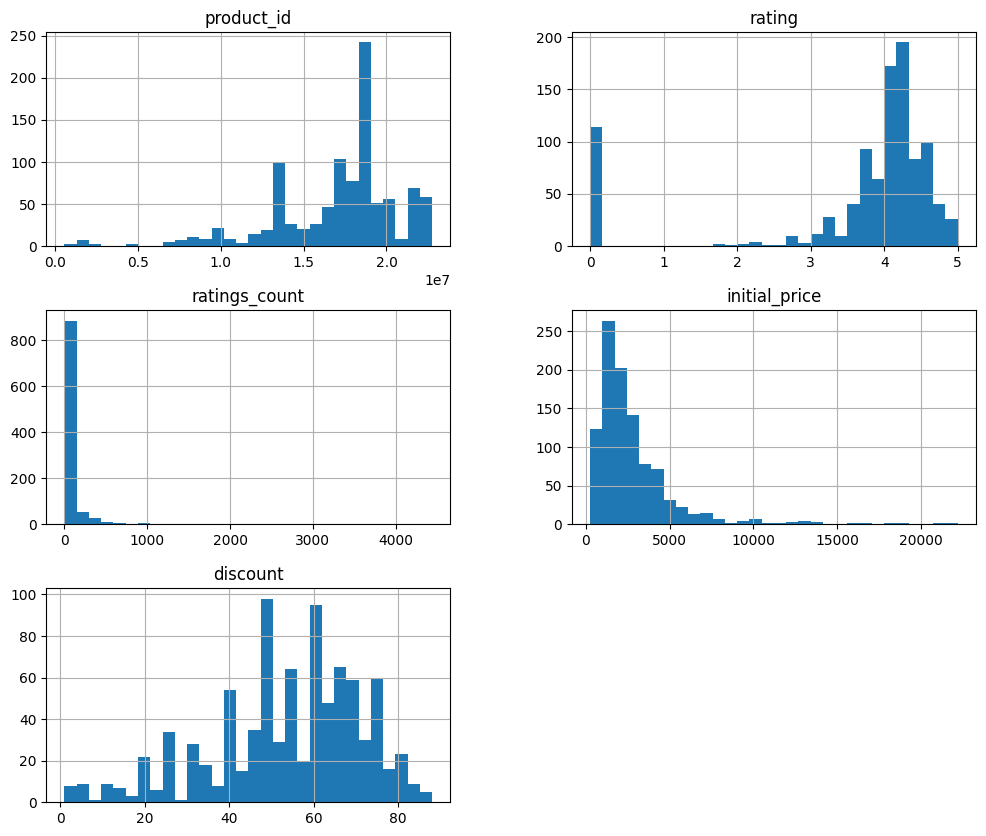

In [29]:
# histograms
df.hist(figsize=(12,10), bins=30)


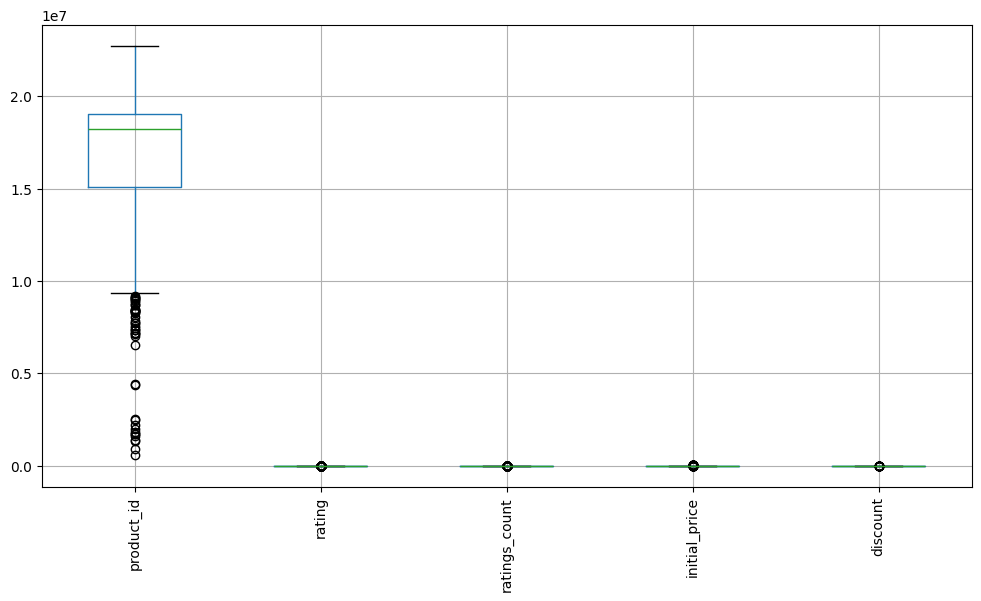

In [33]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Boxplot only on numeric columns
df[numeric_cols].boxplot(figsize=(12,6))
plt.xticks(rotation=90)
plt.show()


In [35]:
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl (36.5 MB)



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: ylabel='Density'>

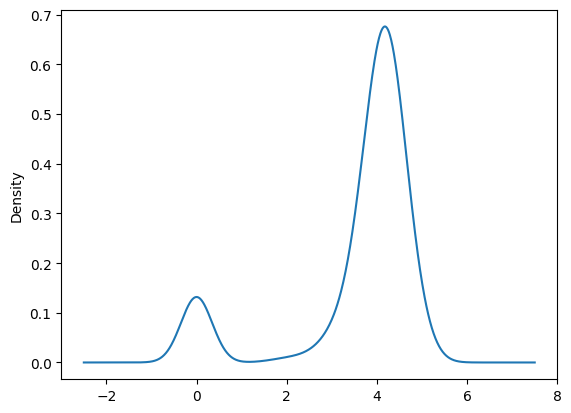

In [36]:
# density plots
df['rating'].plot(kind='density')

### categorical data exploration


<Axes: xlabel='category'>

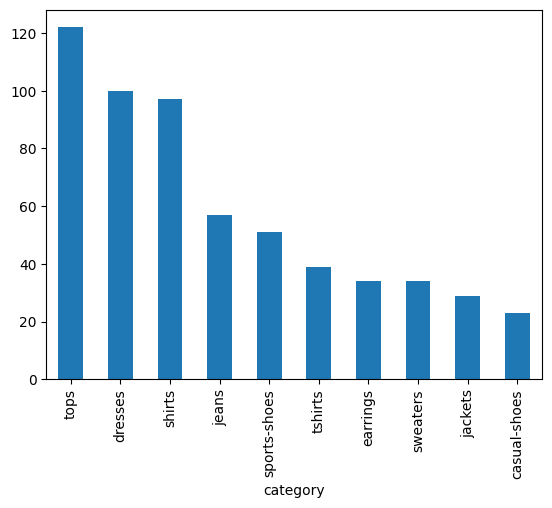

In [37]:
# top cats
df['category'].value_counts().head(10).plot(kind='bar')


In [38]:
# crosstab with rating (e.g., high vs low rated categories)
pd.crosstab(df['category'], pd.cut(df['rating'], bins=[0,2,4,5], labels=['Low','Medium','High']))

rating,Low,Medium,High
category,,,
backpacks,0,1,3
bath-robe,0,0,1
bath-towels,0,1,0
bathroom-accessories,0,0,1
bedsheets,0,4,5
...,...,...,...
tunics,0,0,4
wall-art,0,1,0
wallets,0,0,5


### relationships and correlations

In [41]:
# correlation matrix(numeric cols)
numeric_cols = df.select_dtypes(include=['float64','int64']).columns
corr = df[numeric_cols].corr()
print(corr)


               product_id    rating  ratings_count  initial_price  discount
product_id       1.000000 -0.100663      -0.202165       0.087562  0.026330
rating          -0.100663  1.000000       0.125795      -0.081486 -0.135823
ratings_count   -0.202165  0.125795       1.000000      -0.023120  0.043431
initial_price    0.087562 -0.081486      -0.023120       1.000000  0.136656
discount         0.026330 -0.135823       0.043431       0.136656  1.000000


<Axes: >

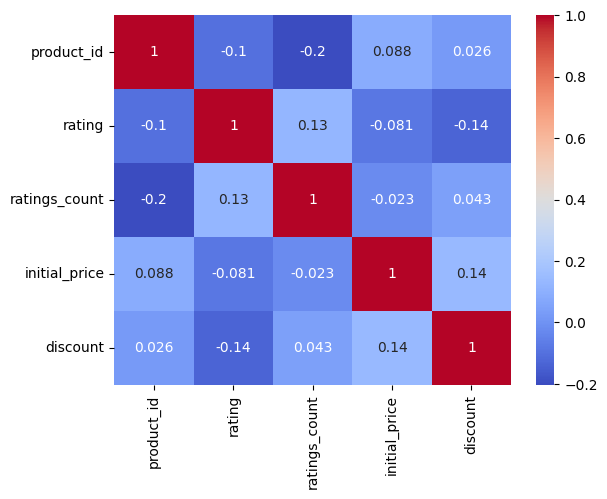

In [42]:
# heatmap (seaborn)
sns.heatmap(corr, annot=True, cmap='coolwarm')


<Axes: xlabel='final_price', ylabel='rating'>

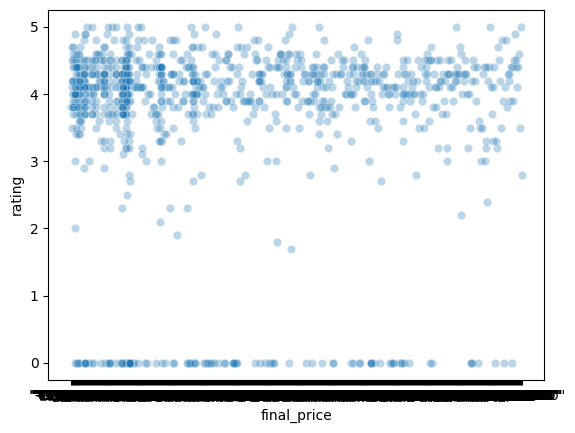

In [43]:
# scatter plot: price vs rating
sns.scatterplot(x='final_price', y='rating', data=df, alpha=0.3)

### text data exploration

In [47]:
# Length of descriptions
df['desc_length'] = df['product_description'].str.len()
df['desc_length'].describe()

count    1000.000000
mean       43.917000
std        14.869674
min        12.000000
25%        33.000000
50%        42.000000
75%        53.000000
max       116.000000
Name: desc_length, dtype: float64

In [45]:
# Most common words in titles  
from collections import Counter
all_words = ' '.join(df['title'].dropna()).split()
Counter(all_words).most_common(10)

[('&', 32),
 ('by', 32),
 ('Roadster', 30),
 ('U.S.', 25),
 ('Polo', 25),
 ('Assn.', 25),
 ('Levis', 21),
 ('Mast', 17),
 ('Harbour', 17),
 ('Flying', 17)]

### handle missing values


In [57]:
df['rating'] = df['rating'].fillna(df['rating'].median())
df['ratings_count'] = df['ratings_count'].fillna(0)
df['discount'] = df['discount'].fillna(0)
df['product_description'] = df['product_description'].fillna('')
df['seller_name'] = df['seller_name'].fillna('Unknown Seller')

# dropping columns that are mostly useless after cleaning
cols_to_drop = ['what_customers_said', 'videos', 'seller_information', 'variations', 'more_offers']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print("after handling missing values:", df.shape)

after handling missing values: (1000, 20)


In [58]:
initial_len = len(df)
df.drop_duplicates(subset=['product_id'], keep='first', inplace=True)
print(f"Removed {initial_len - len(df)} duplicate rows based on product_id.")

Removed 0 duplicate rows based on product_id.


In [70]:
#no. of outliers
Q1 = df['final_price'].quantile(0.25)
Q3 = df['final_price'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['final_price'] < Q1 - 1.5*IQR) | (df['final_price'] > Q3 + 1.5*IQR)]
print(f"Number of price outliers: {len(outliers)}")

Number of price outliers: 67


### filtering

In [60]:
# Convert final_price to numeric if it still contains symbols 
df['final_price'] = df['final_price'].astype(str).str.replace('₹', '').str.replace(',', '').str.extract(r'(\d+\.?\d*)').astype(float)

df = df[df['final_price'] > 0]
df = df[df['rating'].between(0, 5)]
df = df[df['discount'].between(0, 100)]

print("After filtering:", df.shape)

After filtering: (1000, 20)


### adding derived cols

In [65]:

#df['initial_price'] = df['initial_price'].astype(str).str.replace('₹', '').str.replace(',', '').str.extract('(\d+\.?\d*)').astype(float)

# derived columns(discount amount and disc. % cal)
df['discount_amount'] = df['initial_price'] - df['final_price']
df['discount_percentage_calc'] = (df['discount_amount'] / df['initial_price']) * 100
df['discount_ratio'] = (df['initial_price'] - df['final_price']) / df['initial_price']

# weighted rating (normalized by max ratings_count)
max_ratings = df['ratings_count'].max()
df['weighted_rating'] = df['rating'] * (df['ratings_count'] / max_ratings)

# adding quantity = 1 (if you want a total_amount column)
df['quantity'] = 1
df['total_amount'] = df['final_price'] * df['quantity']

print("new columns added:", df.columns.tolist())

new columns added: ['product_id', 'title', 'product_description', 'rating', 'ratings_count', 'initial_price', 'discount', 'final_price', 'currency', 'images', 'delivery_options', 'product_details', 'breadcrumbs', 'product_specifications', 'amount_of_stars', 'seller_name', 'sizes', 'best_offer', 'category', 'desc_length', 'discount_amount', 'discount_percentage_calc', 'weighted_rating', 'quantity', 'total_amount', 'discount_ratio']


### removing unwanted cols 
 

In [66]:
cols_to_remove = ['images', 'delivery_options', 'product_details', 'breadcrumbs', 'product_specifications', 'best_offer']
df.drop(columns=cols_to_remove, inplace=True, errors='ignore')
print("After dropping unnecessary columns:", df.shape)

After dropping unnecessary columns: (1000, 20)


### save clean csv


In [67]:
print("Remaining missing values per column:\n", df.isnull().sum())



Remaining missing values per column:
 product_id                  0
title                       0
product_description         0
rating                      0
ratings_count               0
initial_price               0
discount                    0
final_price                 0
currency                    0
amount_of_stars             0
seller_name                 0
sizes                       0
category                    0
desc_length                 0
discount_amount             0
discount_percentage_calc    0
weighted_rating             0
quantity                    0
total_amount                0
discount_ratio              0
dtype: int64


In [68]:

df.to_csv('cleaned_ecommerce.csv', index=False)
print("cleaned dataset saved as 'cleaned_ecommerce.csv'")

cleaned dataset saved as 'cleaned_ecommerce.csv'
